# 🦠 Feature Engineering & Analytical Modeling
## Global COVID-19 Pandemic Analysis — Member 2

**Role:** Feature Engineering & Analytical Modeling Engineer  
**Input:** `data/owid_covid_cleaned.csv` (output from Member 1)  
**Outputs:**
- `data/processed/final_dataset.csv` — Full enriched dataset
- `data/processed/country_summary.csv` — Country-level aggregates
- `data/processed/continent_summary.csv` — Continent-level aggregates
- `data/processed/global_summary.csv` — Global daily aggregates

---
### 📋 Notebook Structure
1. Setup & Data Loading
2. Exploratory Missing Value Analysis
3. Missing Value Imputation
4. Feature Engineering (KPIs)
5. Time-Series Enhancements (Rolling Averages)
6. Data Aggregation (Country / Continent / Global)
7. Export Final Datasets


# ***path***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Libraries imported successfully")


 Libraries imported successfully


In [3]:
# ── Load cleaned data from Member 1 ──────────────────────────────────────────
INPUT_PATH = '/content/drive/MyDrive/COVID_Project/data/owid_covid_cleaned.csv'
OUTPUT_DIR = '/content/drive/MyDrive/COVID_Project/data/processed'

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_PATH)

# Parse date column
df['date'] = pd.to_datetime(df['date'])

print(f" Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Countries  : {df['location'].nunique()}")
print(f"   Continents : {df['continent'].nunique()}")


 Data loaded: 395,311 rows × 70 columns
   Date range : 2020-01-01 → 2024-08-14
   Countries  : 237
   Continents : 6


## 2. Exploratory Missing Value Analysis

Before imputing anything, we first understand the pattern and extent of missing values
across all 70 columns. This informs which strategy to apply to each column.


In [4]:
# ── Missing value summary table ───────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(1)
dtype_series  = df.dtypes.astype(str)

missing_df = pd.DataFrame({
    'Column'       : missing_count.index,
    'Missing Count': missing_count.values,
    'Missing %'    : missing_pct.values,
    'Dtype'        : dtype_series.values
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns WITH missing values: {len(missing_df)} / {df.shape[1]}")
print()
print(missing_df.to_string(index=False))


Columns WITH missing values: 50 / 70

                                    Column  Missing Count  Missing %   Dtype
      excess_mortality_cumulative_absolute         381948      96.60 float64
               excess_mortality_cumulative         381948      96.60 float64
                          excess_mortality         381948      96.60 float64
   excess_mortality_cumulative_per_million         381948      96.60 float64
                     weekly_icu_admissions         372963      94.30 float64
         weekly_icu_admissions_per_million         372963      94.30 float64
                    weekly_hosp_admissions         362045      91.60 float64
        weekly_hosp_admissions_per_million         362045      91.60 float64
                 hosp_patients_per_million         356640      90.20 float64
                             hosp_patients         356640      90.20 float64
                  icu_patients_per_million         356017      90.10 float64
                              icu_pati

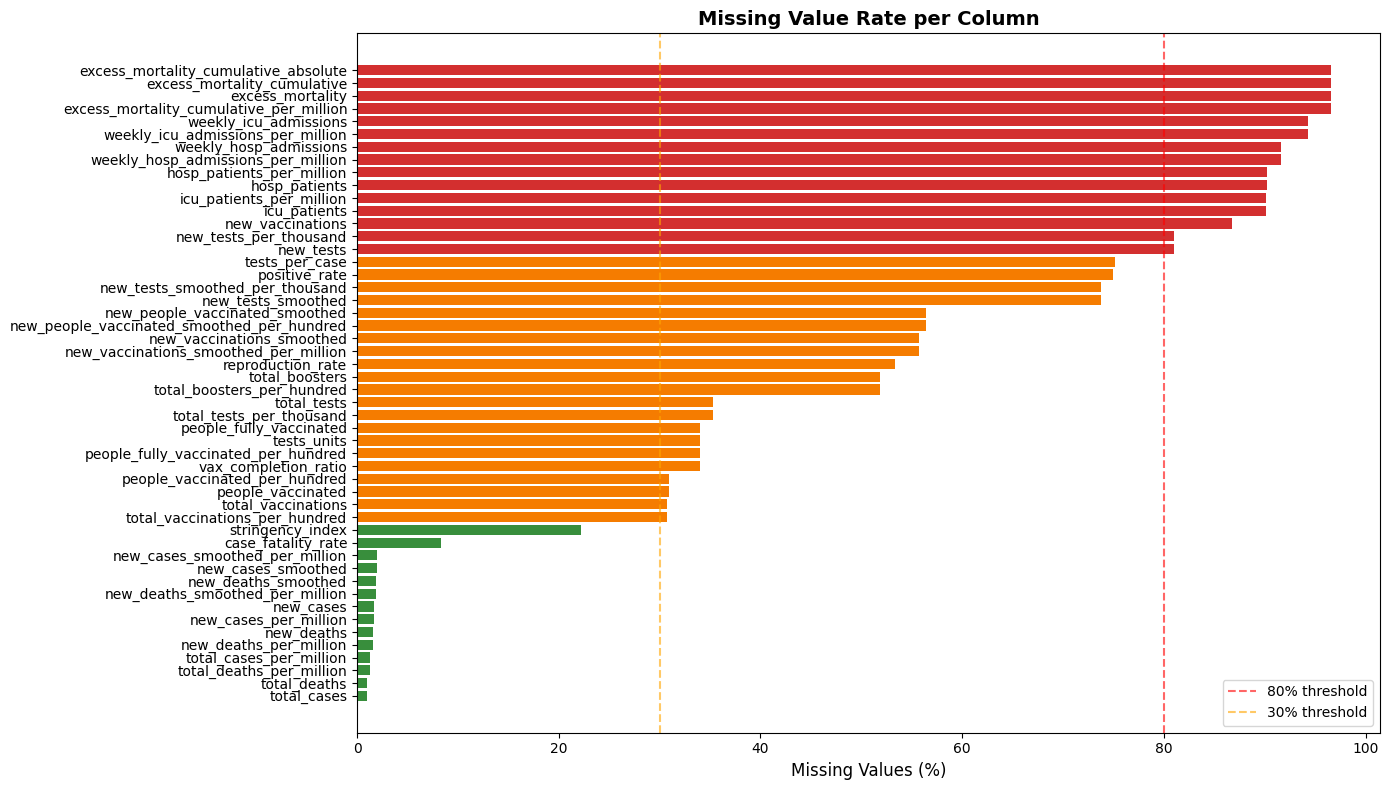

 Chart saved → data/processed/missing_values_overview.png


In [5]:
# ── Visualise missing % by column group ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#d32f2f' if p > 80 else '#f57c00' if p > 30 else '#388e3c'
          for p in missing_df['Missing %']]

ax.barh(missing_df['Column'], missing_df['Missing %'], color=colors)
ax.axvline(x=80, color='red',    linestyle='--', alpha=0.6, label='80% threshold')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.6, label='30% threshold')
ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Missing Value Rate per Column', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/missing_values_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved → data/processed/missing_values_overview.png")


### 📌 Missing Value Strategy — Column by Column

| Column Group | Missing % | Strategy | Reason |
|---|---|---|---|
| `total_cases`, `total_deaths` | ~1% | **Forward Fill** per country | Cumulative — never decreases |
| `new_cases`, `new_deaths` | ~1.7% | **Fill 0** | No report on that day = 0 new events |
| `new_cases_smoothed`, `new_deaths_smoothed` | ~2% | **Fill 0** | Derived from new daily values |
| `*_per_million` (cases/deaths) | ~1–2% | **Fill 0** | Derived from above |
| `reproduction_rate` | 53% | **Keep NaN** | No reliable substitute; used selectively |
| `icu_patients`, `hosp_patients`, `weekly_*` | 90–94% | **Keep NaN** | Reported by very few countries |
| `total_tests`, `total_tests_per_thousand` | 35% | **Forward Fill** per country | Cumulative |
| `new_tests`, `positive_rate`, `tests_per_case` | 73–81% | **Fill 0 / Keep NaN** | Only available where testing programs exist |
| `tests_units` | 34% | **Fill 'Unknown'** | Categorical — unknown is valid |
| `total_vaccinations`, `people_vaccinated`, `people_fully_vaccinated` | 30–34% | **Forward Fill** per country | Cumulative; started late in pandemic |
| `total_boosters`, `new_vaccinations_smoothed` | 51–56% | **Forward Fill → Fill 0** | Boosters rolled out later |
| `stringency_index` | 22% | **Forward Fill** per country | Changes slowly; safe to carry forward |
| `case_fatality_rate` | 8.3% | **Recalculate** | Recompute from deaths/cases |
| `vax_completion_ratio` | 34% | **Recalculate** | Recompute from fully_vaccinated/population |
| `excess_mortality_*` | 96.6% | **Keep NaN** | Only ~4% of rows have this data |
| Static columns (GDP, age, density…) | 0% | ✅ No action | Already handled by Member 1 |


## 3. Missing Value Imputation

In [6]:
# ── Sort by country + date before any fill operation ─────────────────────────
df = df.sort_values(['location', 'date']).reset_index(drop=True)
print(" Data sorted by [location, date]")


 Data sorted by [location, date]


In [7]:
# ── 3.1  Cumulative columns → Forward Fill per country ───────────────────────
cumulative_cols = [
    'total_cases', 'total_deaths',
    'total_cases_per_million', 'total_deaths_per_million',
    'total_tests', 'total_tests_per_thousand',
    'total_vaccinations', 'total_vaccinations_per_hundred',
    'people_vaccinated', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated', 'people_fully_vaccinated_per_hundred',
    'total_boosters', 'total_boosters_per_hundred',
]

df[cumulative_cols] = (
    df.groupby('location')[cumulative_cols]
      .transform(lambda g: g.ffill())
)

# Fill any remaining NaN (countries with no data at all) with 0
df[cumulative_cols] = df[cumulative_cols].fillna(0)

print(f" Forward-filled {len(cumulative_cols)} cumulative columns")


 Forward-filled 14 cumulative columns


In [8]:
# ── 3.2  Daily new values → Fill 0 ────────────────────────────────────────────
daily_zero_cols = [
    'new_cases', 'new_deaths',
    'new_cases_smoothed', 'new_deaths_smoothed',
    'new_cases_per_million', 'new_deaths_per_million',
    'new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million',
    'new_tests', 'new_tests_per_thousand',
    'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
    'new_vaccinations',
    'new_vaccinations_smoothed', 'new_vaccinations_smoothed_per_million',
    'new_people_vaccinated_smoothed', 'new_people_vaccinated_smoothed_per_hundred',
]

df[daily_zero_cols] = df[daily_zero_cols].fillna(0)

print(f" Filled {len(daily_zero_cols)} daily columns with 0")


 Filled 17 daily columns with 0


In [9]:
# ── 3.3  Stringency index → Forward Fill per country ─────────────────────────
df['stringency_index'] = (
    df.groupby('location')['stringency_index']
      .transform(lambda g: g.ffill().bfill())
)
df['stringency_index'] = df['stringency_index'].fillna(0)

print(" stringency_index: forward-filled per country")


 stringency_index: forward-filled per country


In [10]:
# ── 3.4  Total boosters → Forward Fill then 0 ────────────────────────────────
booster_cols = ['total_boosters', 'total_boosters_per_hundred']
df[booster_cols] = (
    df.groupby('location')[booster_cols]
      .transform(lambda g: g.ffill())
      .fillna(0)
)

print(" Booster columns: forward-filled per country, remaining → 0")


 Booster columns: forward-filled per country, remaining → 0


In [11]:
# ── 3.5  tests_units → Fill 'Unknown' ────────────────────────────────────────
df['tests_units'] = df['tests_units'].fillna('Unknown')

print(" tests_units: NaN → 'Unknown'")


 tests_units: NaN → 'Unknown'


In [12]:
# ── 3.6  Validate imputation ─────────────────────────────────────────────────
imputed_cols = cumulative_cols + daily_zero_cols + booster_cols + ['stringency_index', 'tests_units']

remaining = df[imputed_cols].isnull().sum()
still_missing = remaining[remaining > 0]

if still_missing.empty:
    print(" All targeted columns fully imputed — 0 missing values remain")
else:
    print("  Some missing values remain (expected for intentionally kept columns):")
    print(still_missing)


 All targeted columns fully imputed — 0 missing values remain


In [13]:
# ── Columns intentionally kept as NaN (no imputation) ────────────────────────
kept_nan_cols = [
    'reproduction_rate',
    'icu_patients', 'icu_patients_per_million',
    'hosp_patients', 'hosp_patients_per_million',
    'weekly_icu_admissions', 'weekly_icu_admissions_per_million',
    'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million',
    'positive_rate', 'tests_per_case',
    'excess_mortality_cumulative_absolute',
    'excess_mortality_cumulative',
    'excess_mortality',
    'excess_mortality_cumulative_per_million',
]

print("ℹ  The following columns are intentionally kept as NaN:")
print("   (Too sparse or no logical substitute)")
for col in kept_nan_cols:
    pct = df[col].isnull().mean() * 100
    print(f"   • {col:<50} {pct:.1f}% missing")


ℹ  The following columns are intentionally kept as NaN:
   (Too sparse or no logical substitute)
   • reproduction_rate                                  53.3% missing
   • icu_patients                                       90.1% missing
   • icu_patients_per_million                           90.1% missing
   • hosp_patients                                      90.2% missing
   • hosp_patients_per_million                          90.2% missing
   • weekly_icu_admissions                              94.3% missing
   • weekly_icu_admissions_per_million                  94.3% missing
   • weekly_hosp_admissions                             91.6% missing
   • weekly_hosp_admissions_per_million                 91.6% missing
   • positive_rate                                      75.0% missing
   • tests_per_case                                     75.2% missing
   • excess_mortality_cumulative_absolute               96.6% missing
   • excess_mortality_cumulative                        96.6% m

## 4. Feature Engineering — New KPI Columns

We generate 5 analytical KPIs that standardise metrics across countries of different
sizes, enabling fair comparison in visualisation.


In [14]:
# ── 4.1  Cases per Million ────────────────────────────────────────────────────
# More accurate than using the pre-existing column (recalculated from cleaned data)
df['cases_per_million'] = np.where(
    df['population'] > 0,
    (df['total_cases'] / df['population']) * 1_000_000,
    np.nan
).round(2)

print(" cases_per_million  → total_cases / population × 1,000,000")
print(f"   Sample: {df[['location','date','cases_per_million']].dropna().head(3).to_string(index=False)}")


 cases_per_million  → total_cases / population × 1,000,000
   Sample:    location       date  cases_per_million
Afghanistan 2020-01-05               0.00
Afghanistan 2020-01-06               0.00
Afghanistan 2020-01-07               0.00


In [15]:
# ── 4.2  Deaths per Million ───────────────────────────────────────────────────
df['deaths_per_million'] = np.where(
    df['population'] > 0,
    (df['total_deaths'] / df['population']) * 1_000_000,
    np.nan
).round(2)

print(" deaths_per_million → total_deaths / population × 1,000,000")


 deaths_per_million → total_deaths / population × 1,000,000


In [16]:
# ── 4.3  Vaccination Rate % ───────────────────────────────────────────────────
# % of total population fully vaccinated
df['vaccination_rate_pct'] = np.where(
    df['population'] > 0,
    (df['people_fully_vaccinated'] / df['population']) * 100,
    np.nan
).round(2)

# Cap at 100% (some datasets report > 100 due to boosters counted as full doses)
df['vaccination_rate_pct'] = df['vaccination_rate_pct'].clip(upper=100)

print(" vaccination_rate_pct → (people_fully_vaccinated / population) × 100")
print(f"   Range: {df['vaccination_rate_pct'].min():.1f}% – {df['vaccination_rate_pct'].max():.1f}%")


 vaccination_rate_pct → (people_fully_vaccinated / population) × 100
   Range: 0.0% – 100.0%


In [17]:
# ── 4.4  Case Fatality Rate (CFR) — Recalculate & Fill gaps ──────────────────
# CFR = (total_deaths / total_cases) × 100
df['case_fatality_rate'] = np.where(
    df['total_cases'] > 0,
    (df['total_deaths'] / df['total_cases']) * 100,
    np.nan
).round(3)

print(" case_fatality_rate → (total_deaths / total_cases) × 100")
print(f"   Global average CFR: {df['case_fatality_rate'].mean():.2f}%")


 case_fatality_rate → (total_deaths / total_cases) × 100
   Global average CFR: 11.38%


In [18]:
# ── 4.5  Testing Rate (tests per 1,000 people) ────────────────────────────────
df['testing_rate'] = np.where(
    df['population'] > 0,
    (df['total_tests'] / df['population']) * 1_000,
    np.nan
).round(2)

print(" testing_rate → (total_tests / population) × 1,000")
print(f"   Max testing rate: {df['testing_rate'].max():.0f} tests per 1,000 people")


 testing_rate → (total_tests / population) × 1,000
   Max testing rate: 32926 tests per 1,000 people


In [19]:
# ── Summary of new feature columns ───────────────────────────────────────────
new_features = [
    'cases_per_million',
    'deaths_per_million',
    'vaccination_rate_pct',
    'case_fatality_rate',
    'testing_rate'
]

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
summary = df[new_features].describe().T[['count','mean','min','max']]
summary['non-null %'] = (df[new_features].notnull().mean() * 100).round(1)
print(summary.to_string())


FEATURE ENGINEERING SUMMARY
                         count      mean  min       max  non-null %
cases_per_million    395311.00 111539.87 0.00 777237.23      100.00
deaths_per_million   395311.00    812.75 0.00   6489.80      100.00
vaccination_rate_pct 395311.00     31.97 0.00    100.00      100.00
case_fatality_rate   362487.00     11.38 0.00 103875.00       91.70
testing_rate         395311.00    911.83 0.00  32925.83      100.00


## 5. Time-Series Enhancements — Rolling Averages

COVID daily counts are very noisy (weekend reporting dips, batch corrections).
A **7-day rolling average** removes this noise and reveals true trends.


In [20]:
# ── 5.1  7-Day Moving Average — Cases ────────────────────────────────────────
df['cases_7day_ma'] = (
    df.groupby('location')['new_cases']
      .transform(lambda g: g.rolling(window=7, min_periods=1).mean())
      .round(2)
)

print(" cases_7day_ma  → 7-day rolling mean of new_cases  (per country)")


 cases_7day_ma  → 7-day rolling mean of new_cases  (per country)


In [21]:
# ── 5.2  7-Day Moving Average — Deaths ───────────────────────────────────────
df['deaths_7day_ma'] = (
    df.groupby('location')['new_deaths']
      .transform(lambda g: g.rolling(window=7, min_periods=1).mean())
      .round(2)
)

print(" deaths_7day_ma → 7-day rolling mean of new_deaths (per country)")


 deaths_7day_ma → 7-day rolling mean of new_deaths (per country)


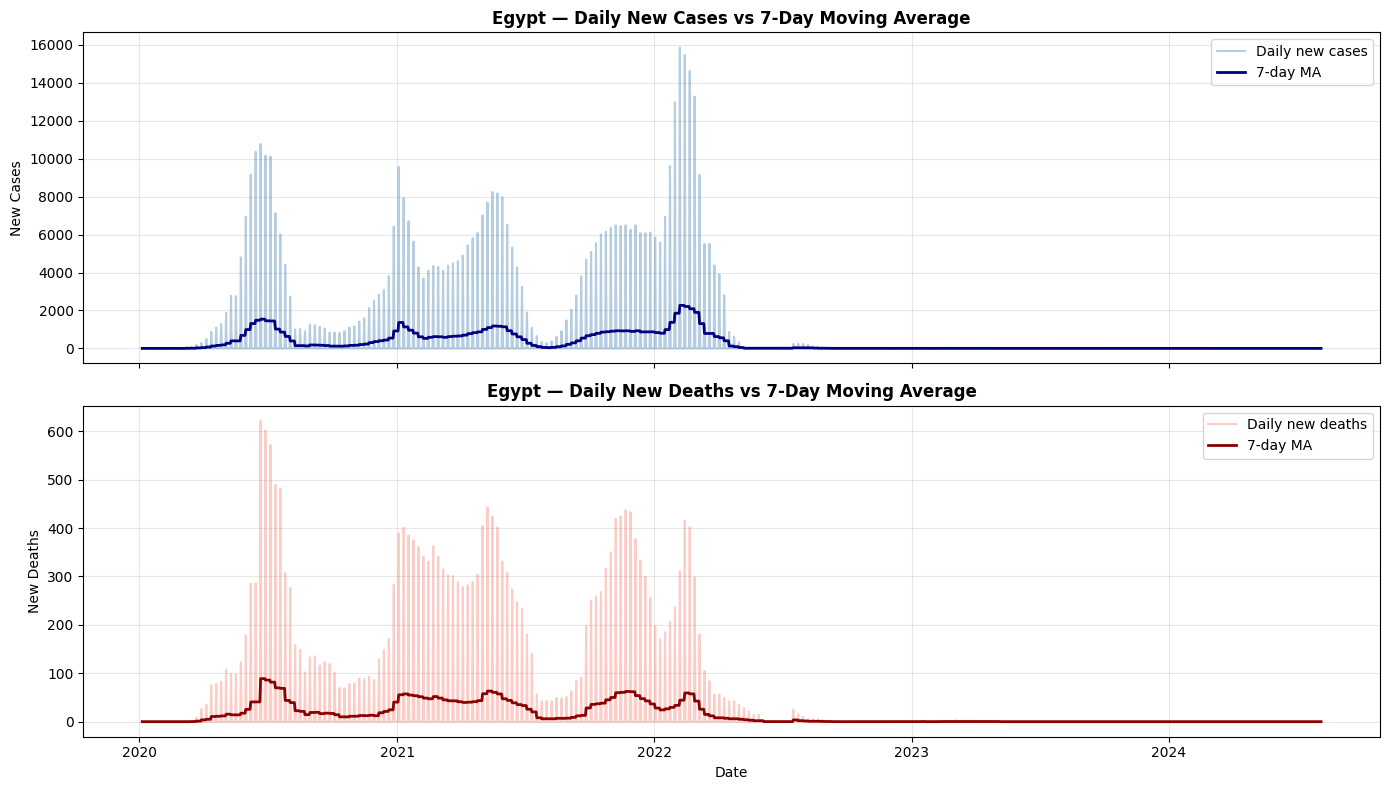

 Chart saved → data/processed/rolling_average_example.png


In [22]:
# ── 5.3  Visualise raw vs smoothed (example: Egypt) ──────────────────────────
country_example = 'Egypt'
eg = df[df['location'] == country_example].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cases
axes[0].plot(eg['date'], eg['new_cases'],      alpha=0.4, color='steelblue', label='Daily new cases')
axes[0].plot(eg['date'], eg['cases_7day_ma'],  color='navy',  linewidth=2,   label='7-day MA')
axes[0].set_title(f'{country_example} — Daily New Cases vs 7-Day Moving Average', fontweight='bold')
axes[0].set_ylabel('New Cases')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Deaths
axes[1].plot(eg['date'], eg['new_deaths'],     alpha=0.4, color='salmon', label='Daily new deaths')
axes[1].plot(eg['date'], eg['deaths_7day_ma'], color='darkred', linewidth=2, label='7-day MA')
axes[1].set_title(f'{country_example} — Daily New Deaths vs 7-Day Moving Average', fontweight='bold')
axes[1].set_ylabel('New Deaths')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rolling_average_example.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Chart saved → data/processed/rolling_average_example.png")


## 6. Data Aggregation

We produce three aggregated datasets to power different chart types in the dashboard:
- **Country summary** — one row per country (latest snapshot)
- **Continent summary** — aggregated continent-level KPIs
- **Global summary** — global daily totals for time-series charts


In [23]:
# ── 6.1  Country-Level Summary ────────────────────────────────────────────────
# Take the latest available row per country (most up-to-date snapshot)
country_summary = (
    df.sort_values('date')
      .groupby('location')
      .last()
      .reset_index()
)

# Select the most useful columns
country_cols = [
    'location', 'continent', 'date', 'population',
    'total_cases', 'total_deaths', 'total_tests', 'total_vaccinations',
    'people_fully_vaccinated',
    'cases_per_million', 'deaths_per_million',
    'vaccination_rate_pct', 'case_fatality_rate', 'testing_rate',
    'gdp_per_capita', 'median_age', 'aged_65_older',
    'population_density', 'life_expectancy',
    'human_development_index', 'hospital_beds_per_thousand',
    'stringency_index',
]

country_summary = country_summary[[c for c in country_cols if c in country_summary.columns]]

print(f" Country summary: {country_summary.shape[0]} countries × {country_summary.shape[1]} columns")
country_summary.head(3)


 Country summary: 237 countries × 22 columns


,location,continent,date,population,total_cases,total_deaths,total_tests,total_vaccinations,people_fully_vaccinated,cases_per_million,deaths_per_million,vaccination_rate_pct,case_fatality_rate,testing_rate,gdp_per_capita,median_age,aged_65_older,population_density,life_expectancy,human_development_index,hospital_beds_per_thousand,stringency_index
0,Afghanistan,Asia,2024-08-04,41128772.00,235214.00,7998.00,994894.00,22964750.00,18370386.00,5718.96,194.46,44.67,3.40,24.19,1803.99,18.60,2.58,54.42,64.83,0.51,0.50,0.00
1,Albania,Europe,2024-08-04,2842318.00,335047.00,3605.00,1613870.00,3088966.00,1279333.00,117878.08,1268.33,45.01,1.08,567.80,11803.43,38.00,13.19,104.87,78.57,0.80,2.89,11.11
2,Algeria,Africa,2024-08-04,44903228.00,272139.00,6881.00,230553.00,15267442.00,6481186.00,6060.57,153.24,14.43,2.53,5.13,13913.84,29.10,6.21,17.35,76.88,0.75,1.90,11.11


In [24]:
# ── 6.2  Continent-Level Summary ──────────────────────────────────────────────
continent_summary = country_summary.groupby('continent').agg(
    num_countries          = ('location',              'count'),
    total_population       = ('population',            'sum'),
    total_cases            = ('total_cases',           'sum'),
    total_deaths           = ('total_deaths',          'sum'),
    total_vaccinations     = ('total_vaccinations',    'sum'),
    avg_cases_per_million  = ('cases_per_million',     'mean'),
    avg_deaths_per_million = ('deaths_per_million',    'mean'),
    avg_vaccination_rate   = ('vaccination_rate_pct',  'mean'),
    avg_cfr                = ('case_fatality_rate',    'mean'),
    avg_testing_rate       = ('testing_rate',          'mean'),
    avg_gdp_per_capita     = ('gdp_per_capita',        'mean'),
    avg_life_expectancy    = ('life_expectancy',       'mean'),
).reset_index().round(2)

print(f" Continent summary: {continent_summary.shape[0]} continents × {continent_summary.shape[1]} columns")
continent_summary


 Continent summary: 6 continents × 13 columns


,continent,num_countries,total_population,total_cases,total_deaths,total_vaccinations,avg_cases_per_million,avg_deaths_per_million,avg_vaccination_rate,avg_cfr,avg_testing_rate,avg_gdp_per_capita,avg_life_expectancy
0,Africa,58,1426736614.00,13145540.00,259118.00,863237900.00,46072.35,311.89,32.96,1.73,135.24,6337.96,65.05
1,Asia,50,4721455390.00,301532347.00,1637249.00,9103443096.00,137884.69,640.18,64.30,1.46,1562.78,23447.34,74.61
2,Europe,50,745629155.00,252642589.00,2099271.00,1397496762.00,407300.46,2672.94,62.28,0.89,4047.89,30640.52,79.31
3,North America,41,600323657.00,124492666.00,1671178.00,1158547416.00,231807.60,1519.81,48.13,1.05,761.10,20899.30,77.29
4,Oceania,24,45038907.00,15003352.00,32918.00,88358812.00,244059.78,557.95,52.66,0.34,471.46,14253.99,73.87
5,South America,14,436816679.00,68809418.00,1355939.00,964991405.00,183750.59,2365.75,61.20,1.79,575.97,13668.20,75.89


In [25]:
# ── 6.3  Global Daily Summary ─────────────────────────────────────────────────
# Aggregate across all countries per date (exclude aggregated OWID regions)
# OWID marks real countries with a non-null continent
real_countries = df[df['continent'].notna() & (df['continent'] != '')]

global_summary = real_countries.groupby('date').agg(
    total_cases        = ('total_cases',     'sum'),
    total_deaths       = ('total_deaths',    'sum'),
    total_vaccinations = ('total_vaccinations', 'sum'),
    new_cases          = ('new_cases',       'sum'),
    new_deaths         = ('new_deaths',      'sum'),
    cases_7day_ma      = ('cases_7day_ma',   'sum'),
    deaths_7day_ma     = ('deaths_7day_ma',  'sum'),
    countries_reporting= ('location',        'nunique'),
).reset_index().round(2)

print(f" Global summary: {global_summary.shape[0]} days × {global_summary.shape[1]} columns")
global_summary.tail(5)


 Global summary: 1688 days × 9 columns


,date,total_cases,total_deaths,total_vaccinations,new_cases,new_deaths,cases_7day_ma,deaths_7day_ma,countries_reporting
1683,2024-08-10,59731951.00,631575.00,2339746237.00,0.00,0.00,643.71,2.43,7
1684,2024-08-11,59731951.00,631575.00,2318747230.00,0.00,0.00,0.00,0.00,6
1685,2024-08-12,57092903.00,627291.00,2305348848.00,0.00,0.00,0.00,0.00,5
1686,2024-08-13,6678765.00,47161.00,77262138.00,0.00,0.00,0.00,0.00,2
1687,2024-08-14,6678765.00,47161.00,77262153.00,0.00,0.00,0.00,0.00,2


In [26]:
# ── 6.4  Quick sanity check on aggregations ───────────────────────────────────
print("AGGREGATION SANITY CHECK")
print("=" * 50)
print(f"Country count          : {country_summary['location'].nunique()}")
print(f"Continents covered     : {continent_summary['continent'].tolist()}")
print(f"Global date range      : {global_summary['date'].min().date()} → {global_summary['date'].max().date()}")
print(f"Global total cases (M) : {global_summary['total_cases'].max() / 1e6:.1f}M")
print(f"Global total deaths (M): {global_summary['total_deaths'].max() / 1e6:.2f}M")


AGGREGATION SANITY CHECK
Country count          : 237
Continents covered     : ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
Global date range      : 2020-01-01 → 2024-08-14
Global total cases (M) : 775.6M
Global total deaths (M): 7.06M


## 7. Export Final Datasets

In [27]:
# ── Full enriched dataset ─────────────────────────────────────────────────────
FINAL_PATH      = f'{OUTPUT_DIR}/final_dataset.csv'
COUNTRY_PATH    = f'{OUTPUT_DIR}/country_summary.csv'
CONTINENT_PATH  = f'{OUTPUT_DIR}/continent_summary.csv'
GLOBAL_PATH     = f'{OUTPUT_DIR}/global_summary.csv'

df.to_csv(FINAL_PATH, index=False)
country_summary.to_csv(COUNTRY_PATH, index=False)
continent_summary.to_csv(CONTINENT_PATH, index=False)
global_summary.to_csv(GLOBAL_PATH, index=False)

print(" All datasets exported successfully:")
print(f"    {FINAL_PATH:<45} {os.path.getsize(FINAL_PATH)/1e6:.1f} MB")
print(f"    {COUNTRY_PATH:<45} {os.path.getsize(COUNTRY_PATH)/1024:.0f} KB")
print(f"    {CONTINENT_PATH:<45} {os.path.getsize(CONTINENT_PATH)/1024:.0f} KB")
print(f"    {GLOBAL_PATH:<45} {os.path.getsize(GLOBAL_PATH)/1024:.0f} KB")


 All datasets exported successfully:
    /content/drive/MyDrive/COVID_Project/data/processed/final_dataset.csv 151.8 MB
    /content/drive/MyDrive/COVID_Project/data/processed/country_summary.csv 38 KB
    /content/drive/MyDrive/COVID_Project/data/processed/continent_summary.csv 1 KB
    /content/drive/MyDrive/COVID_Project/data/processed/global_summary.csv 122 KB


In [28]:
# ── Final column inventory ────────────────────────────────────────────────────
original_cols = 70
new_cols = ['cases_per_million', 'deaths_per_million', 'vaccination_rate_pct',
            'case_fatality_rate', 'testing_rate', 'cases_7day_ma', 'deaths_7day_ma']
total_cols = df.shape[1]

print("=" * 60)
print("FEATURE ENGINEERING — FINAL SUMMARY")
print("=" * 60)
print(f"  Input columns      : {original_cols}")
print(f"  New KPI columns    : {len(new_cols)}")
print(f"  Total columns      : {total_cols}")
print(f"  Total rows         : {len(df):,}")
print()
print("  New columns added:")
for c in new_cols:
    non_null = df[c].notnull().mean() * 100
    print(f"     {c:<35} ({non_null:.1f}% non-null)")
print()
print("  Imputation applied to:")
print("    • Cumulative columns → Forward Fill per country")
print("    • Daily new columns  → Filled with 0")
print("    • Stringency index   → Forward Fill per country")
print("    • tests_units        → Filled with 'Unknown'")
print()
print("  Intentionally kept as NaN:")
print("    • reproduction_rate, ICU/hospital data (90–94% sparse)")
print("    • excess_mortality_* (96.6% sparse)")
print()
print(" Feature engineering notebook complete!")
print("   Hand off final_dataset.csv to Members 3, 4, and 5.")


FEATURE ENGINEERING — FINAL SUMMARY
  Input columns      : 70
  New KPI columns    : 7
  Total columns      : 76
  Total rows         : 395,311

  New columns added:
     cases_per_million                   (100.0% non-null)
     deaths_per_million                  (100.0% non-null)
     vaccination_rate_pct                (100.0% non-null)
     case_fatality_rate                  (91.7% non-null)
     testing_rate                        (100.0% non-null)
     cases_7day_ma                       (100.0% non-null)
     deaths_7day_ma                      (100.0% non-null)

  Imputation applied to:
    • Cumulative columns → Forward Fill per country
    • Daily new columns  → Filled with 0
    • Stringency index   → Forward Fill per country
    • tests_units        → Filled with 'Unknown'

  Intentionally kept as NaN:
    • reproduction_rate, ICU/hospital data (90–94% sparse)
    • excess_mortality_* (96.6% sparse)

 Feature engineering notebook complete!
   Hand off final_dataset.csv to